In [29]:
import numpy as np
from PIL import Image
from tqdm import tqdm
from IPython.display import display

In [30]:
img = Image.open('jenna.jpg')
gray_img = img.convert('L')
resized_img = gray_img.resize((500, 500))

In [31]:
np_array = np.array(resized_img)
print(np_array.shape)

(500, 500)


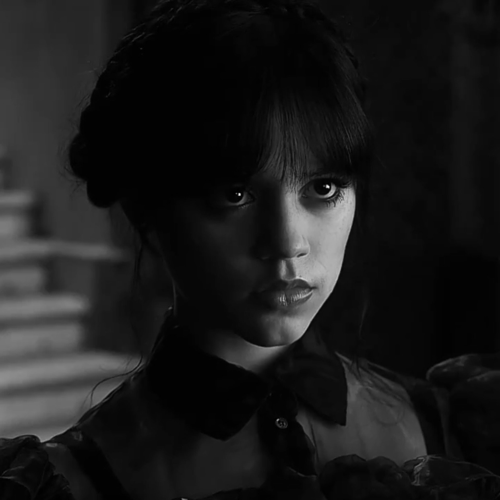

In [32]:
display(resized_img)

In [33]:
np_array

array([[45, 44, 43, ...,  7,  6,  6],
       [45, 44, 43, ...,  7,  6,  6],
       [45, 44, 43, ...,  7,  6,  6],
       ...,
       [ 5,  6,  7, ...,  7,  4,  4],
       [ 5,  6,  8, ...,  4,  3,  3],
       [ 6,  7,  9, ...,  5,  3,  3]], dtype=uint8)

In [34]:
kernel_radius = 5
kernel_1 = np.matrix([[0, 0, 0], [1, 1, 1], [0, 0, 0]])
kernel_2 = np.matrix([[0, 1, 0], [0, 1, 0], [0, 1, 0]])
kernel_3 = np.matrix([[-1,0,1], [-1,0,1], [-1,0,1]])
kernel_4 = np.matrix([[-1,-1,-1], [0,0,0], [1,1,1]])
blur_kernel = np.matrix([[0.1,0.1,0.1], [0.1,0.1,0.1], [0.1,0.1,0.1]])
heavy_blur_kernel = np.full((kernel_radius, kernel_radius), 0.1)

In [35]:
heavy_blur_kernel

array([[0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1]])

In [36]:
np_array[0:3, 0:3]

array([[45, 44, 43],
       [45, 44, 43],
       [45, 44, 43]], dtype=uint8)

In [37]:
np.multiply(np_array[0:3, 0:3], kernel_2)

matrix([[ 0, 44,  0],
        [ 0, 44,  0],
        [ 0, 44,  0]])

In [38]:
result_matrix = np.zeros(np_array.shape)

In [39]:
x,y = result_matrix.shape

In [40]:
#image with blur effect with changable kernel radius
for j in tqdm(range(x-kernel_radius)):
    for k in range(y-kernel_radius):
        arr = np.multiply(np_array[j+0:j+kernel_radius, k+0:k+kernel_radius], heavy_blur_kernel)
        result_matrix[j][k] = np.sum(arr)
image = Image.fromarray(result_matrix)
image.show()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 495/495 [00:04<00:00, 116.11it/s]


In [41]:
#image with vertical edge detector
for j in tqdm(range(x-3)):
    for k in range(y-3):
        arr = np.multiply(np_array[j+0:j+3, k+0:k+3], kernel_3)
        result_matrix[j][k] = np.sum(arr)
image = Image.fromarray(result_matrix)
image.show()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 497/497 [00:06<00:00, 76.88it/s]


In [42]:
#image with horizontal edge detector
for j in tqdm(range(x-3)):
    for k in range(y-3):
        arr = np.multiply(np_array[j+0:j+3, k+0:k+3], kernel_4)
        result_matrix[j][k] = np.sum(arr)
image = Image.fromarray(result_matrix)
image.show()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 497/497 [00:06<00:00, 72.54it/s]


In [43]:
#image with both horizontal and vertical edge detector
for j in tqdm(range(x-3)):
    for k in range(y-3):
        arr1 = np.multiply(np_array[j+0:j+3, k+0:k+3], kernel_3)
        arr2 = np.multiply(np_array[j+0:j+3, k+0:k+3], kernel_4)
        arr = arr1+arr2
        result_matrix[j][k] = np.sum(arr)
image = Image.fromarray(result_matrix)
image.show()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 497/497 [00:09<00:00, 51.11it/s]
